In [1]:
cd Desktop\AI,ML\B6G2-08_AI_ML_PROJECT\notebooks


C:\Users\amintha\Desktop\AI,ML\B6G2-08_AI_ML_PROJECT\notebooks


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/warsaw.csv')
print("Data loaded successfully!")
df.head()




Data loaded successfully!


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,PRCP,SNWD,TAVG,TMAX,TMIN
0,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-01,0.0,10.0,-8.3,NaN,NaN
1,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-02,NaN,10.0,-14.9,NaN,NaN
2,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-03,0.0,10.0,-13.6,-9.7,NaN
3,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-04,0.0,10.0,-10.5,-6.5,-13.3
4,PLM00012375,"OKECIE, PL",52.166,20.967,110.3,1993-01-05,0.0,10.0,-12.0,-8.9,-14.1


In [3]:
# Convert DATE from string to a datetime format
df['DATE'] = pd.to_datetime(df['DATE'])

# Create a function to map the month to a season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Apply the function to create a new 'Season' column
df['Season'] = df['DATE'].dt.month.map(get_season)

# Check the result
df[['DATE', 'Season']].head()


,DATE,Season
0,1993-01-01,Winter
1,1993-01-02,Winter
2,1993-01-03,Winter
3,1993-01-04,Winter
4,1993-01-05,Winter


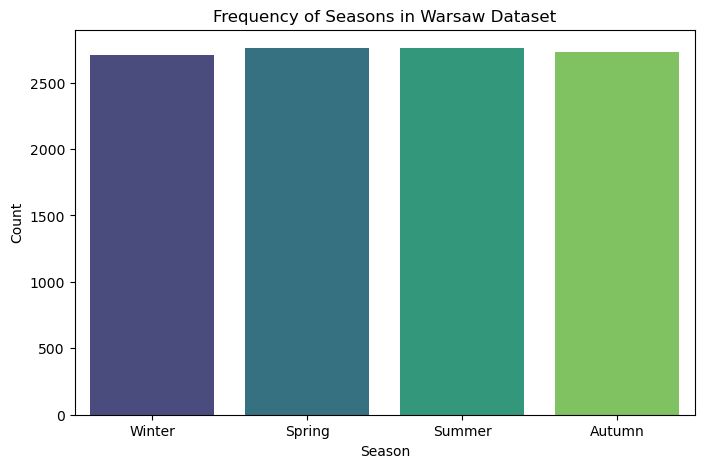

In [6]:
plt.figure(figsize=(8, 5))

# Create the bar chart using Seaborn (updated to remove the warning)
sns.countplot(
    data=df, 
    x='Season', 
    hue='Season',
    order=['Winter', 'Spring', 'Summer', 'Autumn'], 
    palette='viridis',
    legend=False
)

plt.title('Frequency of Seasons in Warsaw Dataset')
plt.xlabel('Season')
plt.ylabel('Count')

# Save the plot image into the results/eda_visualizations folder
plt.savefig('../results/eda_visualizations/seasonal_frequencies_bar_chart.png', bbox_inches='tight')

# Display the plot
plt.show()


In [7]:
# Use pandas to apply One-Hot Encoding to our new 'Season' column
df_encoded = pd.get_dummies(df, columns=['Season'], prefix='Season')

# Show the new encoded columns to prove it worked
encoded_columns = [col for col in df_encoded.columns if 'Season_' in col]
print("New Encoded Columns created:", encoded_columns)

df_encoded[['DATE'] + encoded_columns].head()


New Encoded Columns created: ['Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']


,DATE,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,1993-01-01,False,False,False,True
1,1993-01-02,False,False,False,True
2,1993-01-03,False,False,False,True
3,1993-01-04,False,False,False,True
4,1993-01-05,False,False,False,True
